In [100]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [101]:
# Load data
df = sns.load_dataset('titanic')

In [102]:
# ijad-e vizhegi tarkibi baraye dark behtar model
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)
df['title'] = df['who'] # man, woman, child tasir-e ziadi darad

In [103]:
cols = ['survived', 'pclass', 'sex', 'age', 'fare', 'embarked', 'family_size', 'is_alone', 'title']
df = df[cols].copy()

In [104]:
#por kardan maghadire khali
df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(lambda x: x.fillna(x.median()))
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [105]:
#tabdil be One-Hot Encoding
df = pd.get_dummies(df, columns=['sex', 'embarked', 'pclass', 'title'], drop_first=True)


In [106]:
X = df.drop('survived', axis=1).values.astype(float)
y = df['survived'].values

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [108]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

In [109]:
# 3. Tarrahi Model 
class TitanicRobustNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)
        
        self.fc2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        
        self.fc3 = nn.Linear(16, 1)
        
        # LeakyReLU baraye jolgiri az dead neurona
        self.leaky_relu = nn.LeakyReLU(0.1)
        
        # Meghdardehi avaliye He/Kaiming baraye jolgiri az vanishing gradient
        init.xavier_normal_(self.fc2.weight)
        init.xavier_normal_(self.fc2.weight)
        init.xavier_normal_(self.fc3.weight)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.leaky_relu(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.leaky_relu(x)
        
        return self.fc3(x) 

In [110]:
model = TitanicRobustNet(X_train.shape[1])

In [111]:
criterion = nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
# In khat nerkh LR ro har 50 epoch nesf (0.5) mikone
# Ta model dar avakher amoozesh ba deghat bishtari hamgera beshe.
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

In [112]:
epochs = 1000
train_losses = []
test_accuracies = []

In [113]:
# Train

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    # Jolgiri az enfejar-e gradient (Gradient Clipping)
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    
    model.eval()
    with torch.no_grad():
        test_preds = torch.sigmoid(model(X_test_t)).round()
        acc = (test_preds == y_test_t).float().mean()
        test_accuracies.append(acc.item())
        train_losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | Acc: {acc.item()*100:.2f}%")


Epoch 50/1000 | Loss: 0.3560 | Acc: 81.56%
Epoch 100/1000 | Loss: 0.3232 | Acc: 81.56%
Epoch 150/1000 | Loss: 0.2864 | Acc: 79.89%
Epoch 200/1000 | Loss: 0.2681 | Acc: 79.33%
Epoch 250/1000 | Loss: 0.2597 | Acc: 81.01%
Epoch 300/1000 | Loss: 0.2560 | Acc: 81.56%
Epoch 350/1000 | Loss: 0.2542 | Acc: 81.56%
Epoch 400/1000 | Loss: 0.2533 | Acc: 81.56%
Epoch 450/1000 | Loss: 0.2527 | Acc: 81.56%
Epoch 500/1000 | Loss: 0.2524 | Acc: 81.56%
Epoch 550/1000 | Loss: 0.2523 | Acc: 81.56%
Epoch 600/1000 | Loss: 0.2522 | Acc: 81.56%
Epoch 650/1000 | Loss: 0.2522 | Acc: 81.56%
Epoch 700/1000 | Loss: 0.2522 | Acc: 82.12%
Epoch 750/1000 | Loss: 0.2522 | Acc: 82.12%
Epoch 800/1000 | Loss: 0.2521 | Acc: 82.12%
Epoch 850/1000 | Loss: 0.2521 | Acc: 82.12%
Epoch 900/1000 | Loss: 0.2521 | Acc: 82.12%
Epoch 950/1000 | Loss: 0.2521 | Acc: 82.12%
Epoch 1000/1000 | Loss: 0.2521 | Acc: 82.12%


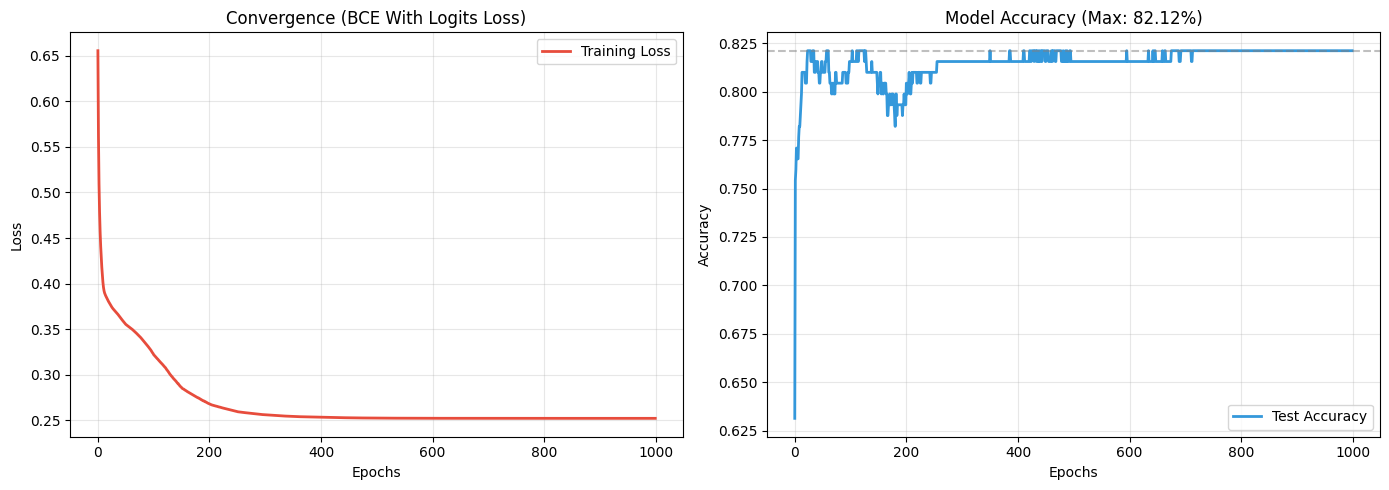

In [114]:
# 6. Rasme Plot-ha (Visualization)
plt.figure(figsize=(14, 5))

# Plot-e Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='#e74c3c', lw=2)
plt.title('Convergence (BCE With Logits Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot-e Accuracy
plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy', color='#3498db', lw=2)
plt.axhline(y=max(test_accuracies), color='gray', linestyle='--', alpha=0.5)
plt.title(f'Model Accuracy (Max: {max(test_accuracies)*100:.2f}%)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()